In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import torch
from RNN import *

## Data Import and Preprocessing

Import raw data:

In [2]:
cpi_urban = pd.read_excel('data/cpi_urban.xlsx')
imf_data = pd.read_csv('data/imf_time_series_govt_exp.csv')
repo_data = pd.read_csv('data/repo.csv')
usdzar_data = pd.read_csv('data/usdzar.csv')
za_real_gdp_data = pd.read_csv('data/za_real_gdp.csv')
zaronia_data = pd.read_csv('data/zaronia.csv')

/var/folders/pr/05vbp6_94f3300tknkj0jbw40000gn/T/ipykernel_66015/3812176795.py:2: DtypeWarning: Columns (13,15,21,24) have mixed types. Specify dtype option on import or set low_memory=False.
  imf_data = pd.read_csv('data/imf_time_series_govt_exp.csv')


Isolate the actual time series data required

In [3]:
# CPI Average Prices All Urban (White Bread)
white_bread_cpi_df = cpi_urban[(cpi_urban['H03']==1113101) & (cpi_urban['H07']==10902)].drop(columns=cpi_urban.columns[0:10]).T.rename(columns={15:'Value'})
white_bread_cpi_df.index = pd.to_datetime(white_bread_cpi_df.index.str[1:], format="%Y%m", errors="coerce")
white_bread_cpi_df = white_bread_cpi_df[white_bread_cpi_df.index.notna()]
white_bread_cpi_df = white_bread_cpi_df.rename_axis("date").reset_index()

# ZARONIA-REPO spread
zaronia_data['Date'] = pd.to_datetime(zaronia_data['Date'])
repo_data['Date'] = pd.to_datetime(repo_data['Date'])
zaronia_data = zaronia_data.set_index('Date')['Rate']
repo_data = repo_data.set_index('Date')['Value']
zaronia_repo_spread_df = (repo_data - zaronia_data).dropna()
zaronia_repo_spread_df = zaronia_repo_spread_df.rename("spread_bps").rename_axis("Date").reset_index()

# South African Real GDP data
za_real_gdp_data.columns = ['Date', 'Value']
za_real_gdp_df = za_real_gdp_data.set_index('Date')['Value'].rename_axis("Date").reset_index()
za_real_gdp_df['Value'] = za_real_gdp_df['Value'] / 1e6

# SA annual government expenditure
sa_govt_exp_df = imf_data[imf_data['SERIES_CODE']=='ZAF.GGX.A'].drop(columns=imf_data.columns[:27]).T.dropna()
sa_govt_exp_df.columns = ['Value']
sa_govt_exp_df.index.rename('Date', inplace=True)
sa_govt_exp_df = sa_govt_exp_df.rename_axis("Date").reset_index()

# USD/ZAR exchange rate data
usdzar_df = usdzar_data.set_index('Date')['Value'].rename_axis("Date").reset_index()

## Plotting of datasets

In [4]:
# attemping to make nice plots for the report
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Inter", "Helvetica Neue", "Arial", "DejaVu Sans"],
    "mathtext.fontset": "custom",
    "pdf.fonttype": 42,
    "savefig.dpi": 600,
    "figure.dpi": 200,
})

def plot_series(df, title=None, ylabel=None, color="blue", savepath=None):
    data = df.iloc[:, :2].copy()
    data.columns = ["date", "value"]
    data["date"] = pd.to_datetime(data["date"])
    data = data.sort_values("date")
    fig, ax = plt.subplots(figsize=(3.5, 2.4))
    ax.plot(data["date"], data["value"], color=color, linewidth=1.5)
    for side in ["top", "right"]:
        ax.spines[side].set_visible(False)
    ax.tick_params(labelsize=9)
    ax.margins(x=0)
    span_years = (data["date"].max() - data["date"].min()).days / 365.25
    if span_years <= 1.5:
        locator = mdates.MonthLocator(interval=2)
    elif span_years <= 3:
        locator = mdates.MonthLocator(interval=6)
    else:
        locator = mdates.YearLocator(base=1 if span_years <= 6 else 4)
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))
    if title:
        ax.set_title(title, loc="left", fontsize=11, fontweight="bold")
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=10)
    fig.tight_layout()
    if savepath:
        fig.savefig(savepath, bbox_inches="tight")
    return fig, ax

(<Figure size 700x480 with 1 Axes>, <Axes: ylabel='ZAR per USD'>)

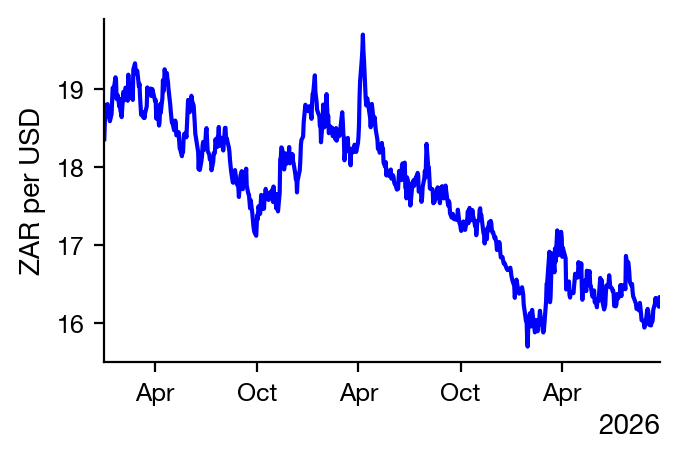

In [5]:
plot_series(usdzar_df, ylabel="ZAR per USD")

## Hyperparam tuning

In [7]:
# just testing the tuning function for now
grid = {
    'window_size': [3,9,12], # input dim size
    'hidden_size': [4,8,16],
    'learning_rate': [1e-3, 1e-2],
    'weight_decay': [0, 1e-4, 1e-3]
}

tune(usdzar_df['Value'].to_numpy(), ElmanRNN, grid, n_splits=3)

,p,n_hidden,lr,wd,val_loss
28,9,8,0.010,0.0001,0.014215
27,9,8,0.010,0.0000,0.014216
29,9,8,0.010,0.0010,0.014341
45,12,8,0.010,0.0000,0.014504
46,12,8,0.010,0.0001,0.014506
51,12,16,0.010,0.0000,0.014508
34,9,16,0.010,0.0001,0.014556
33,9,16,0.010,0.0000,0.014571
47,12,8,0.010,0.0010,0.014738
52,12,16,0.010,0.0001,0.014805


## Model Building

In [ ]:
# just testing the model builging phase for now
from sklearn.model_selection import TimeSeriesSplit
models = {"Elman": ElmanRNN, "Jordan": JordanRNN, "Multi": MultiRNN}
forecasts = {name: np.full(len(zaronia_repo_spread_df), np.nan) for name in models}
dates = usdzar_df.index
values = usdzar_df['Value'].to_numpy(dtype=float)
forecasts = {name: np.full(len(values), np.nan) for name in models}
for tr, te in TimeSeriesSplit(n_splits=3).split(values):
    for name, Model in models.items():
        _, _, pred, idx = run_fold(values, tr, te, Model, seed=0)
        forecasts[name][idx] = pred

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(dates, values, color="black", linewidth=1.2, label="Actual")
for name, f in forecasts.items():
    ax.plot(dates, f, linewidth=1.2, label=name)
for side in ["top", "right"]:
    ax.spines[side].set_visible(False)
ax.legend(frameon=False)
plt.show()